# 12 — Road-access snapping for navigation (Overpass API prototype)

The info-sheet Google Maps link points at the 500m **centroid**, which is often in an empty
field with no road, so routing fails. This prototype finds a **routable road access point** per
sub-cell using the **Overpass API** (OpenStreetMap) — no local road files:

1. Query Overpass for roads in the square's bounding box.
2. Test which roads **cross the 500m square** (we have the square polygons in `selected_subcells`).
3. Snap to the point on those roads **nearest the centroid** (if several cross, the closest wins;
   if none cross, fall back to the nearest road in a widened box).
4. Output `road_lat/lon` + `off_road_m` (the walk from the road to the target) and build a
   directions link to the **road** point.


## Setup

In [12]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import requests
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points

from src.utils.config_loader import load_config, get_data_dir

config = load_config()
data_dir = get_data_dir(config)
SELECTED = data_dir / '01_input_data' / 'boundaries' / 'selected_subcells_500m.gpkg'

UTM = 32736          # metric CRS for distances/intersections

sub = gpd.read_file(SELECTED)
sub_wgs = sub.to_crs(4326)   # squares in lat/lon for the bbox queries
print(f'{len(sub)} sub-cells | native CRS {sub.crs}')
sub_wgs[['grid_id', '5km_id', 'ward_name', 'latitude', 'longitude']].head()

Loaded local config overrides from config.local.yaml
110 sub-cells | native CRS EPSG:32736


,grid_id,5km_id,ward_name,latitude,longitude
0,G_0588_0987,10758.0,Ibumu,-7.305162,36.149334
1,G_0587_0987,10758.0,Malenga Makali,-7.305194,36.144811
2,G_0586_0964,10760.0,Ibumu,-7.409095,36.141019
3,G_0586_0965,10760.0,Ibumu,-7.404579,36.140987
4,G_0587_0964,10760.0,Ibumu,-7.409063,36.145543


## Overpass helpers

Query roads in a bbox and rebuild them as LineStrings. `out geom;` returns each way's full lat/lon geometry, so no extra node lookups.

In [13]:
OVERPASS_URL = 'https://overpass-api.de/api/interpreter'
# A real User-Agent is REQUIRED — overpass-api.de returns 406 for the default
# python-requests UA. Use a descriptive one (with a contact) per OSM usage policy.
HEADERS = {'User-Agent': 'listing-geospatial-cct/1.0 (rlinssen@laterite.com)'}
# drivable road types (skip footways/paths)
HIGHWAY = 'trunk|primary|secondary|tertiary|unclassified|residential|track|service'

def query_roads_bbox(s, w, n, e, highway=HIGHWAY, timeout=60):
    """Roads (ways) whose geometry falls in bbox (south,west,north,east)."""
    q = f'[out:json][timeout:25];way["highway"~"{highway}"]({s},{w},{n},{e});out geom;'
    r = requests.post(OVERPASS_URL, data={'data': q}, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    return r.json()

def roads_to_lines(overpass_json):
    lines = []
    for el in overpass_json.get('elements', []):
        if el.get('type') == 'way' and len(el.get('geometry', [])) >= 2:
            coords = [(p['lon'], p['lat']) for p in el['geometry']]
            lines.append(LineString(coords))
    return lines

def bbox_buffered(geom, buf_deg=0.01):
    """(south,west,north,east) around a geom, padded ~1 km so nearby roads are caught."""
    minx, miny, maxx, maxy = geom.bounds   # lon/lat
    return (miny - buf_deg, minx - buf_deg, maxy + buf_deg, maxx + buf_deg)

## The snap: square -> crossing roads -> nearest point to centroid

In [14]:
def snap_to_road(square_wgs, centroid_wgs, buf_deg=0.01):
    """Return the routable road access point for one sub-cell square.

    square_wgs   : shapely Polygon (EPSG:4326) - the 500m cell outline
    centroid_wgs : shapely Point   (EPSG:4326) - snap target (centroid here)
    """
    s, w, n, e = bbox_buffered(square_wgs, buf_deg)
    lines = roads_to_lines(query_roads_bbox(s, w, n, e))
    if not lines:
        return {'status': 'no_roads_in_bbox'}

    roads = gpd.GeoSeries(lines, crs=4326).to_crs(UTM)
    sq = gpd.GeoSeries([square_wgs], crs=4326).to_crs(UTM).iloc[0]
    cen = gpd.GeoSeries([centroid_wgs], crs=4326).to_crs(UTM).iloc[0]

    crossing = roads[roads.intersects(sq)]
    target = crossing if len(crossing) else roads      # fall back to nearest nearby road
    access = nearest_points(cen, target.union_all())[1]
    access_wgs = gpd.GeoSeries([access], crs=UTM).to_crs(4326).iloc[0]

    return {
        'status': 'crossing' if len(crossing) else 'nearest_only',
        'road_lat': round(access_wgs.y, 6),
        'road_lon': round(access_wgs.x, 6),
        'off_road_m': round(cen.distance(access), 1),
        'n_roads': len(roads),
        'n_crossing': len(crossing),
        # geoms (UTM) kept for plotting
        '_roads': roads, '_crossing': crossing, '_square': sq,
        '_centroid': cen, '_access': access,
    }

## Test on one sub-cell

Change `TEST_GRID_ID` to try others (e.g. a remote cell to see the `nearest_only` fallback).

In [15]:
TEST_GRID_ID = sub_wgs['grid_id'].iloc[0]
row = sub_wgs[sub_wgs['grid_id'] == TEST_GRID_ID].iloc[0]
square = row.geometry
centroid = Point(row['longitude'], row['latitude'])

res = snap_to_road(square, centroid)
print('sub-cell:', TEST_GRID_ID, '| ward:', row['ward_name'])
print('status:        ', res['status'])
print('roads in bbox: ', res.get('n_roads'), '| crossing the square:', res.get('n_crossing'))
print('road access:   ', res.get('road_lat'), res.get('road_lon'))
print('off-road walk: ', res.get('off_road_m'), 'm from centroid to the road')

sub-cell: G_0588_0987 | ward: Ibumu
status:         crossing
roads in bbox:  3 | crossing the square: 2
road access:    -7.304947 36.148801
off-road walk:  63.5 m from centroid to the road


## Visualize: square + centroid + roads + access point

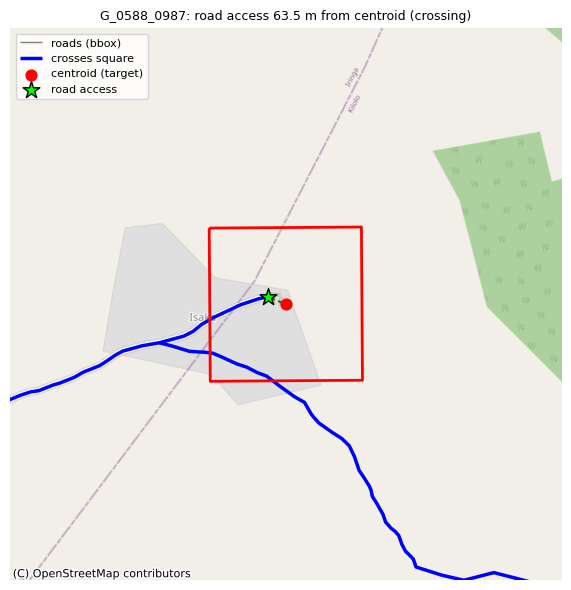

<Axes: title={'center': 'G_0588_0987: road access 63.5 m from centroid (crossing)'}>

In [16]:
import matplotlib.pyplot as plt
import contextily as cx

WM = 3857   # web-mercator, for the basemap tiles

def plot_snap(res, title=None, ax=None, add_basemap=True, legend=False):
    """Little map for one snap result: square + roads + centroid + road access.

    `res` is a dict returned by snap_to_road (must carry the `_*` UTM geoms).
    Pass an `ax` to draw into a gallery subplot; omit it for a standalone figure.
    """
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))

    sqm    = gpd.GeoSeries([res['_square']], crs=UTM).to_crs(WM)
    roadsm = res['_roads'].to_crs(WM)
    crossm = res['_crossing'].to_crs(WM)
    cenm   = gpd.GeoSeries([res['_centroid']], crs=UTM).to_crs(WM)
    accm   = gpd.GeoSeries([res['_access']], crs=UTM).to_crs(WM)
    segm   = gpd.GeoSeries([LineString([res['_centroid'], res['_access']])], crs=UTM).to_crs(WM)

    roadsm.plot(ax=ax, color='grey', linewidth=1.0, zorder=1, label='roads (bbox)')
    if len(crossm):
        crossm.plot(ax=ax, color='blue', linewidth=2.5, zorder=2, label='crosses square')
    sqm.boundary.plot(ax=ax, color='red', linewidth=2.0, zorder=3)
    segm.plot(ax=ax, color='green', linestyle='--', linewidth=1.5, zorder=4)
    cenm.plot(ax=ax, color='red', markersize=60, zorder=5, label='centroid (target)')
    accm.plot(ax=ax, color='lime', markersize=160, marker='*', edgecolor='black',
              zorder=6, label='road access')

    # zoom to the square + access point with padding
    bx = list(sqm.total_bounds)
    pad = max(bx[2]-bx[0], bx[3]-bx[1]) * 1.2 + 300
    cx0, cy0 = (bx[0]+bx[2])/2, (bx[1]+bx[3])/2
    ax.set_xlim(cx0-pad, cx0+pad); ax.set_ylim(cy0-pad, cy0+pad)
    if add_basemap:
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    if legend:
        ax.legend(loc='upper left', fontsize=8)
    ax.set_title(title or f"road access {res['off_road_m']} m from centroid ({res['status']})",
                 fontsize=9)
    ax.set_axis_off()
    if own_fig:
        plt.tight_layout(); plt.show()
    return ax

plot_snap(res, title=f"{TEST_GRID_ID}: road access {res['off_road_m']} m "
                     f"from centroid ({res['status']})", legend=True)

## Directions links to the *road* access point

In [17]:
def osm_dir(lat, lon):
    return f'https://www.openstreetmap.org/directions?to={lat:.6f},{lon:.6f}'

def gmaps_dir(lat, lon):
    return f'https://www.google.com/maps/dir/?api=1&destination={lat:.6f},{lon:.6f}'

def gmaps_pin(lat, lon):
    """A view/pin link (not directions) — drops a marker at the point."""
    return f'https://www.google.com/maps/search/?api=1&query={lat:.6f},{lon:.6f}'

print('centroid pin :', gmaps_pin(row['latitude'], row['longitude']))
print('road pin     :', gmaps_pin(res['road_lat'], res['road_lon']))
print('road dir     :', gmaps_dir(res['road_lat'], res['road_lon']))
print('road OSM dir :', osm_dir(res['road_lat'], res['road_lon']))
print(f"(then ~{res['off_road_m']:.0f} m on foot from the road to the centroid)")

centroid pin : https://www.google.com/maps/search/?api=1&query=-7.305162,36.149334
road pin     : https://www.google.com/maps/search/?api=1&query=-7.304947,36.148801
road dir     : https://www.google.com/maps/dir/?api=1&destination=-7.304947,36.148801
road OSM dir : https://www.openstreetmap.org/directions?to=-7.304947,36.148801
(then ~64 m on foot from the road to the centroid)


## Batch over a sample (with a polite delay)

Runs the snap for the first few sub-cells so you can see the result table without hammering the
public Overpass server. For the real run, set `SAMPLE_N = len(sub_wgs)` and **cache** the result
(e.g. write `grid_id, road_lat, road_lon, off_road_m, status` to a CSV) so info-sheet generation
stays offline. Keep the `time.sleep` to respect Overpass usage limits.

In [18]:
SAMPLE_N = 5

snap_results = {}   # grid_id -> full snap dict (keeps the `_*` geoms for plot_snap)
rows = []
for _, r in sub_wgs.head(SAMPLE_N).iterrows():
    gid = r['grid_id']
    clat, clon = r['latitude'], r['longitude']
    try:
        out = snap_to_road(r.geometry, Point(clon, clat))
        snap_results[gid] = out
        has_road = out.get('road_lat') is not None
        rows.append({
            'grid_id': gid, 'ward_name': r['ward_name'],
            'status': out['status'],
            'centroid_lat': clat, 'centroid_lon': clon,
            'road_lat': out.get('road_lat'), 'road_lon': out.get('road_lon'),
            'off_road_m': out.get('off_road_m'), 'n_crossing': out.get('n_crossing'),
            'gmaps_centroid': gmaps_pin(clat, clon),
            'gmaps_road': gmaps_pin(out['road_lat'], out['road_lon']) if has_road else None,
        })
    except Exception as ex:
        rows.append({'grid_id': gid, 'status': f'error: {ex}'})
    time.sleep(1.5)   # be polite to overpass-api.de

snap_df = pd.DataFrame(rows)
snap_df

,grid_id,ward_name,status,centroid_lat,centroid_lon,road_lat,road_lon,off_road_m,n_crossing,gmaps_centroid,gmaps_road
0,G_0588_0987,Ibumu,crossing,-7.305162,36.149334,-7.304947,36.148801,63.5,2.0,https://www.google.com/maps/search/?api=1&quer...,https://www.google.com/maps/search/?api=1&quer...
1,G_0587_0987,Malenga Makali,crossing,-7.305194,36.144811,-7.306387,36.145073,135.2,2.0,https://www.google.com/maps/search/?api=1&quer...,https://www.google.com/maps/search/?api=1&quer...
2,G_0586_0964,Ibumu,nearest_only,-7.409095,36.141019,-7.411710,36.141236,290.5,0.0,https://www.google.com/maps/search/?api=1&quer...,https://www.google.com/maps/search/?api=1&quer...
3,G_0586_0965,NaN,error: 504 Server Error: Gateway Timeout for u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,G_0587_0964,NaN,error: 504 Server Error: Gateway Timeout for u...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clickable Google Maps links (centroid + road access)

`gmaps_centroid` pins the 500m centroid; `gmaps_road` pins the routable road access point.
Rendering the table as HTML makes both columns clickable.

In [19]:
from IPython.display import HTML

link_cols = ['grid_id', 'ward_name', 'status', 'off_road_m', 'gmaps_centroid', 'gmaps_road']
HTML(snap_df[link_cols].to_html(render_links=True, escape=False, index=False))

grid_id,ward_name,status,off_road_m,gmaps_centroid,gmaps_road
G_0588_0987,Ibumu,crossing,63.5,"https://www.google.com/maps/search/?api=1&query=-7.305162,36.149334","https://www.google.com/maps/search/?api=1&query=-7.304947,36.148801"
G_0587_0987,Malenga Makali,crossing,135.2,"https://www.google.com/maps/search/?api=1&query=-7.305194,36.144811","https://www.google.com/maps/search/?api=1&query=-7.306387,36.145073"
G_0586_0964,Ibumu,nearest_only,290.5,"https://www.google.com/maps/search/?api=1&query=-7.409095,36.141019","https://www.google.com/maps/search/?api=1&query=-7.411710,36.141236"
G_0586_0965,NaN,error: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter,NaN,NaN,NaN
G_0587_0964,NaN,error: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter,NaN,NaN,NaN


## Little maps for every sub-cell in `snap_df`

One small `plot_snap` panel per sub-cell (square + roads + centroid + road access), using the
geometries cached in `snap_results` during the batch — no extra Overpass calls.

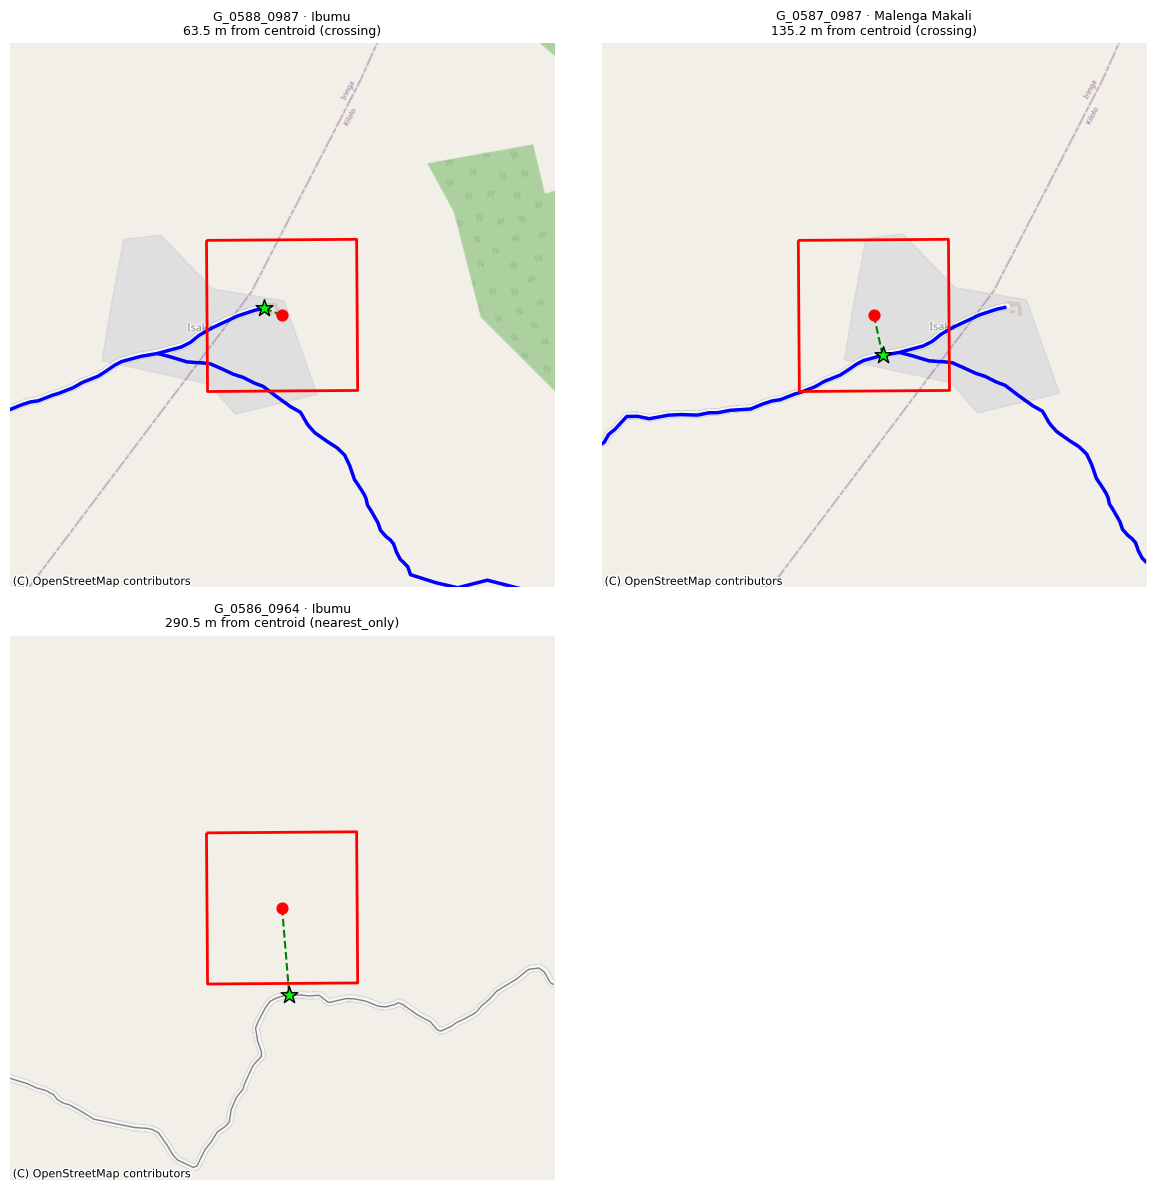

In [20]:
import math

# only cells that actually produced geometry (skip errors / no_roads_in_bbox)
plottable = [g for g in snap_df['grid_id'] if g in snap_results and '_square' in snap_results[g]]

NCOL = 2
nrow = max(1, math.ceil(len(plottable) / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(6 * NCOL, 6 * nrow))
axes = axes.flatten() if len(plottable) > 1 else [axes]

for ax, gid in zip(axes, plottable):
    res_g = snap_results[gid]
    ward = snap_df.loc[snap_df['grid_id'] == gid, 'ward_name'].iloc[0]
    plot_snap(res_g, ax=ax,
              title=f"{gid} · {ward}\n{res_g['off_road_m']} m from centroid ({res_g['status']})")

for ax in axes[len(plottable):]:   # blank any unused panels
    ax.set_axis_off()

plt.tight_layout(); plt.show()